In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv("train.csv", usecols=["FireplaceQu", "GarageQual", "SalePrice"])

In [23]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   FireplaceQu  770 non-null    object
 1   GarageQual   1379 non-null   object
 2   SalePrice    1460 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 34.3+ KB


In [25]:
df.shape

(1460, 3)

In [26]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [27]:
df["GarageQual"].value_counts()

GarageQual
TA    1311
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64

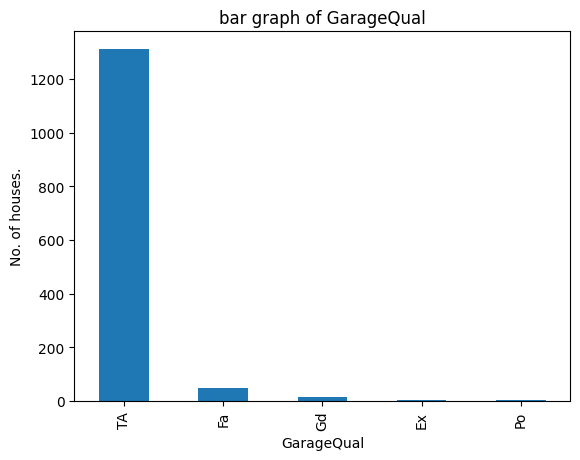

In [28]:
df["GarageQual"].value_counts().plot(kind="bar")
plt.xlabel("GarageQual")
plt.ylabel("No. of houses.")
plt.title("bar graph of GarageQual")
plt.show()

In [29]:
df["GarageQual"].mode()

0    TA
Name: GarageQual, dtype: object

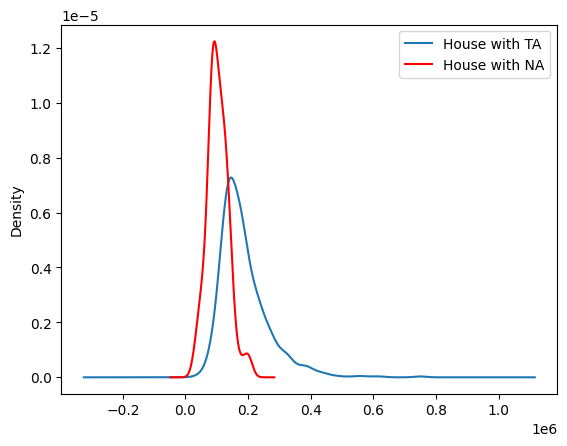

In [30]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df["GarageQual"] == "TA"]["SalePrice"].plot(kind="kde", ax=ax)
df[df["GarageQual"].isnull()]["SalePrice"].plot(kind="kde", ax=ax, color="red")

lines, labels = ax.get_legend_handles_labels()
labels = ["House with TA", "House with NA"]
ax.legend(lines , labels, loc="best")
plt.show()

In [31]:
temp = df[df["GarageQual"] == "TA"]["SalePrice"]

In [32]:
df["GarageQual"].fillna("TA", inplace=True)

In [33]:
df["GarageQual"].value_counts()

GarageQual
TA    1392
Fa      48
Gd      14
Ex       3
Po       3
Name: count, dtype: int64

<Axes: xlabel='GarageQual'>

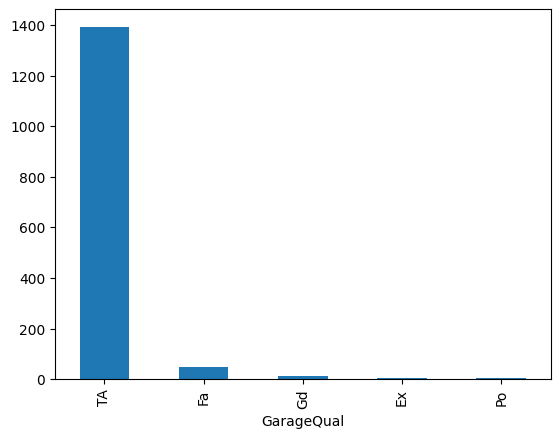

In [34]:
df["GarageQual"].value_counts().plot(kind = "bar")

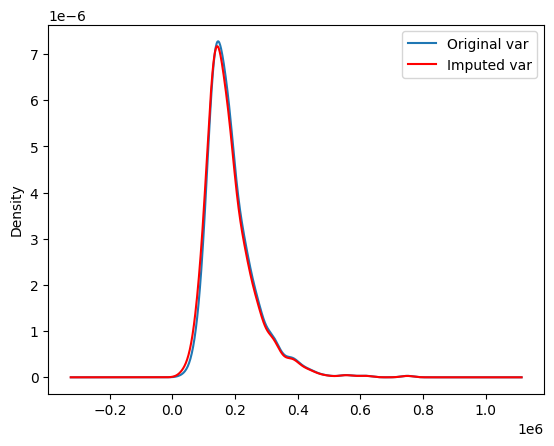

In [37]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind="kde", ax=ax)
df[df["GarageQual"] == "TA"]["SalePrice"].plot(kind="kde", ax=ax, c="red")

lines, labels = ax.get_legend_handles_labels()
labels = ["Original var", "Imputed var"]
ax.legend(lines , labels, loc="best")
plt.show()

In [38]:
# Now on Fire column

In [39]:
df["FireplaceQu"].value_counts()

FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64

<Axes: xlabel='FireplaceQu'>

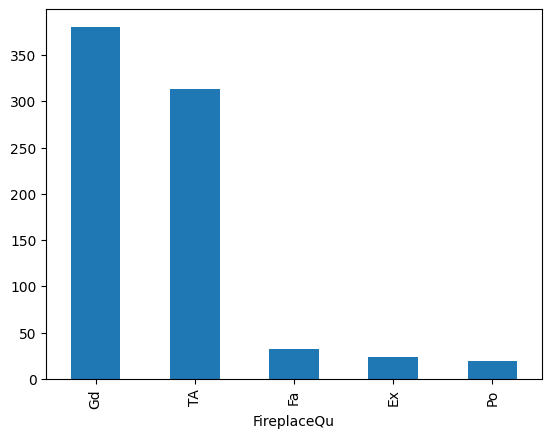

In [40]:
df["FireplaceQu"].value_counts().plot(kind="bar")

In [41]:
df["FireplaceQu"].mode()

0    Gd
Name: FireplaceQu, dtype: object

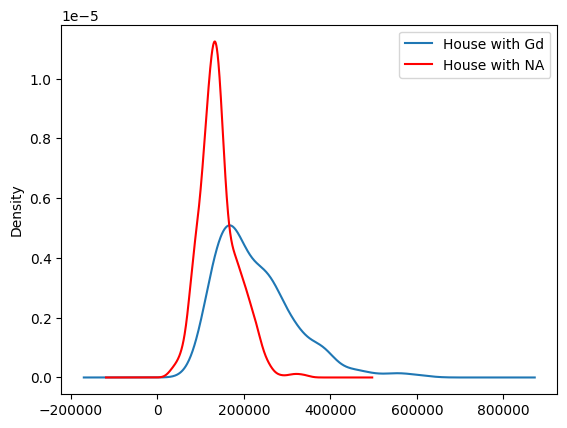

In [42]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df["FireplaceQu"] == "Gd"]["SalePrice"].plot(kind="kde", ax=ax)
df[df["FireplaceQu"].isnull()]["SalePrice"].plot(kind="kde", ax=ax, color="red")

lines, labels = ax.get_legend_handles_labels()
labels = ["House with Gd", "House with NA"]
ax.legend(lines , labels, loc="best")
plt.show()

In [43]:
temp = df[df["FireplaceQu"] == "Gd"]["SalePrice"]

In [44]:
df["FireplaceQu"].fillna("Gd", inplace=True)

In [47]:
df["FireplaceQu"].value_counts()

FireplaceQu
Gd    1070
TA     313
Fa      33
Ex      24
Po      20
Name: count, dtype: int64

<Axes: xlabel='FireplaceQu'>

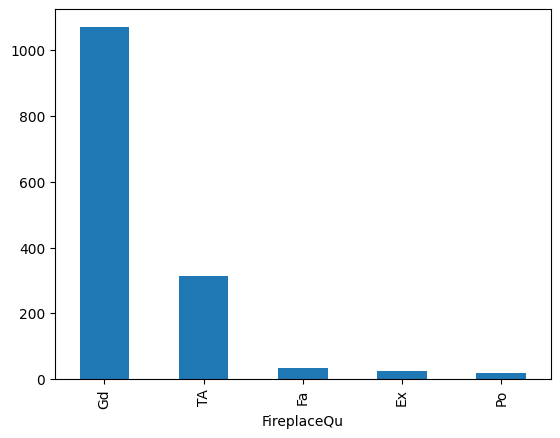

In [48]:
df["FireplaceQu"].value_counts().plot(kind="bar")

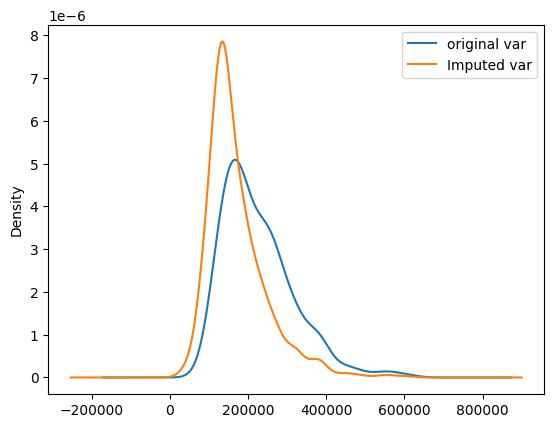

In [50]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind="kde", ax=ax)
df[df["FireplaceQu"] == "Gd"]["SalePrice"].plot(kind="kde", ax=ax)

lines, labels = ax.get_legend_handles_labels()
labels = ["original var", "Imputed var"]
ax.legend(lines , labels, loc="best")
plt.show()

In [51]:
# Now using sklearn

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [54]:
X_train, X_test, y_train, y_test = train_test_split(df.drop("SalePrice", axis=1), df["SalePrice"], test_size=0.2, random_state=42)

In [55]:
X_train.head()

,FireplaceQu,GarageQual
254,Gd,TA
1066,TA,TA
638,Gd,TA
799,TA,TA
380,Gd,TA


In [58]:
imputer = SimpleImputer(strategy="most_frequent")

In [59]:
X_train_trf = imputer.fit_transform(X_train)
X_test_trf = imputer.transform(X_test)

In [61]:
X_train_trf

array([['Gd', 'TA'],
       ['TA', 'TA'],
       ['Gd', 'TA'],
       ...,
       ['Gd', 'TA'],
       ['Gd', 'TA'],
       ['TA', 'TA']], dtype=object)

In [62]:
imputer

SimpleImputer(strategy='most_frequent')

In [63]:
imputer.feature_names_in_

array(['FireplaceQu', 'GarageQual'], dtype=object)

In [67]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)